# Case 3 Preliminary -- Half-Max / Pearson Alignment (Poplar Branch)

**Dissertation Chapter 6, Section 6.3, "Branched Structures" (p. 120):**

> Half-maximum analysis yielded velocities of 6.93 +/- 18.0% mm/min for the upper region,
> 1.16 +/- 29.1% mm/min for the side branch, and 4.73 +/- 4.9% mm/min for the lower region.

Preliminary analysis preceding the main MCT+CSTR fit (`case3_branched_structure_poplar_branch.ipynb`).
Reproduces `fig:poplar_branch_pearson`, `fig:poplar_branch_alignment`, and the `fig:branch_hmax`
half-max/distance-time-fit panels (upper/side/lower).

In [1]:
import os
os.makedirs("output/figures", exist_ok=True)


In [2]:
import sys; sys.path.insert(0, "..")
from utils import *
import pandas as pd
import matplotlib.pyplot as plt
from scipy.linalg import lstsq
from scipy import stats
import seaborn as sns

from scipy import interpolate

#from intercept_ransac import *
#


In [3]:
dfuplow = pd.read_csv("data/case3_branch_lowup.csv", index_col=0)
dfuplow.columns = dfuplow.columns.astype(float)  # CSV headers are strings; these are numeric distances (mm)
dfuplow = dfuplow.iloc[:]

dfside = pd.read_csv("data/case3_branch_side.csv", index_col=0)
dfside.columns = dfside.columns.astype(float)
dfside = dfside.iloc[:]

xiuplow=list(dfuplow.columns)
xiuplow = np.array(xiuplow)[[3,4,5,6,11,12,13,14]]
t=dfuplow.index.to_numpy()

data_cor_uplow=dfuplow[xiuplow].to_numpy(dtype=float)

data_unc_uplow=dfuplow[xiuplow].to_numpy(dtype=float)*np.exp(-0.000567*60*t.reshape(len(t),1))

xiside=list(dfside.columns)
xiside = xiside[1:5]
xi_side = xiside
t=dfside.index.to_numpy()

data_side_cor=dfside[xiside].to_numpy(dtype=float)

data_side_unc=dfside[xiside].to_numpy(dtype=float)*np.exp(-0.000567*60*t.reshape(len(t),1))

xi_up_end = np.array(xiuplow)[3]
xi_up = np.array(xiuplow)[0:4]-np.array(xiuplow)[0]
xi_low_start = np.array(xiuplow)[4]
xi_low = np.array(xiuplow)[4:]-np.array(xiuplow)[4]

xi_side = np.array(xi_side)-xi_side[0]

data_up_cor = data_cor_uplow[:, 0:4]
data_up_unc = data_unc_uplow[:, 0:4]

data_low_cor = data_cor_uplow[:, 4:]
data_low_unc = data_unc_uplow[:, 4:]

In [4]:
t

array([  0.,   5.,  10.,  15.,  20.,  25.,  30.,  35.,  40.,  45.,  50.,
        55.,  60.,  65.,  70.,  75.,  80.,  85.,  90.,  95., 100., 105.,
       110., 115., 120., 125., 130., 135., 140., 145., 150., 155., 160.,
       165., 170., 175., 180., 185., 190., 195., 200., 205.])

In [5]:
steps=len(data_up_unc)

d_up_xi=[]

for i in range(1,len(xi_up)):
     d_up_xi.append(float(xi_up[i])-float(xi_up[i-1]))


In [6]:
steps=len(data_side_unc)

d_side_xi=[]

for i in range(1,len(xi_side)):
     d_side_xi.append(float(xi_side[i])-float(xi_side[i-1]))


In [7]:
steps=len(data_low_unc)

d_low_xi=[]

for i in range(1,len(xi_low)):
     d_low_xi.append(float(xi_low[i])-float(xi_low[i-1]))


In [8]:
df_up = pd.DataFrame(data_up_cor, columns=xi_up)
df_low = pd.DataFrame(data_low_cor, columns=xi_low)
df_side = pd.DataFrame(data_side_cor, columns=xi_side)

In [9]:
xi_side

array([ 0.   , 11.744, 23.488, 35.23 ])

In [10]:
df_side

,0.000,11.744,23.488,35.230
0,118.322619,130.929216,135.158640,140.672003
1,178.281714,192.724858,209.606117,236.830544
2,163.386006,178.458188,189.858761,208.529515
3,162.657838,175.108431,176.419012,194.712786
4,158.500232,168.398433,189.961843,199.865308
5,215.894203,225.307389,230.531760,238.049420
6,376.312926,386.222312,336.452185,323.590928
7,803.049988,753.000173,555.516299,470.539997
8,1995.145922,1405.172729,930.877909,750.012920
9,5012.227682,3055.617451,1615.132687,1142.733264


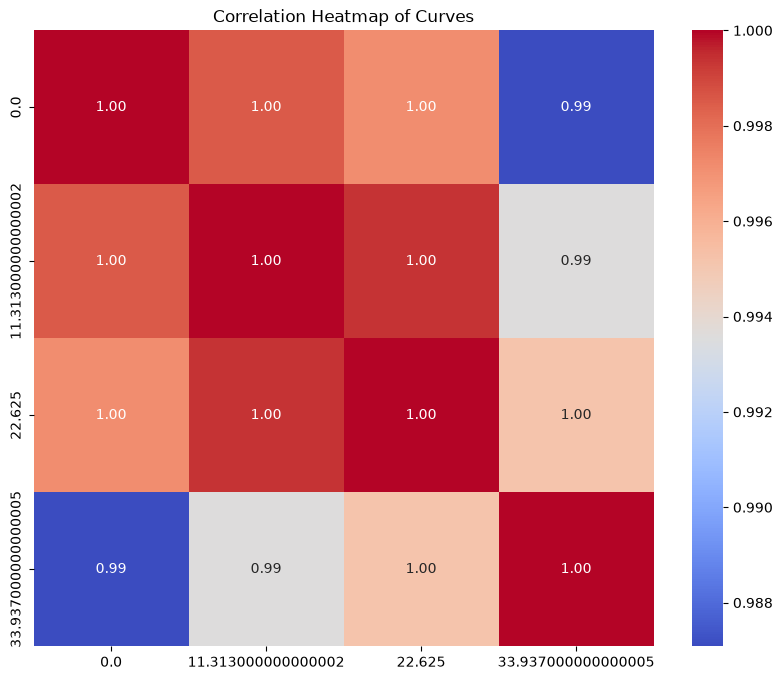

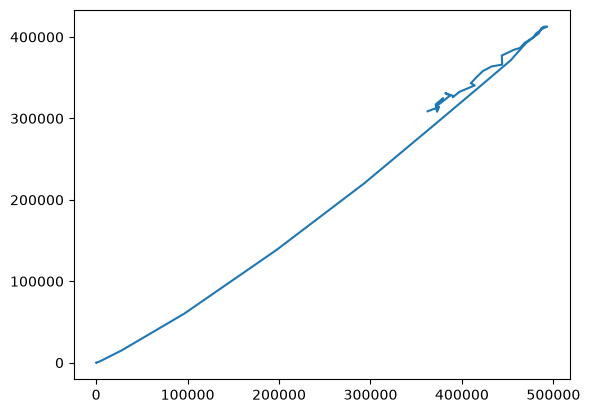

In [11]:
plt.figure(figsize=(10, 8))
sns.heatmap(df_up[xi_up[:]].corr(method="pearson"), annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Correlation Heatmap of Curves")
plt.show()

plt.plot(data_up_cor[:,0],data_up_cor[:,1])

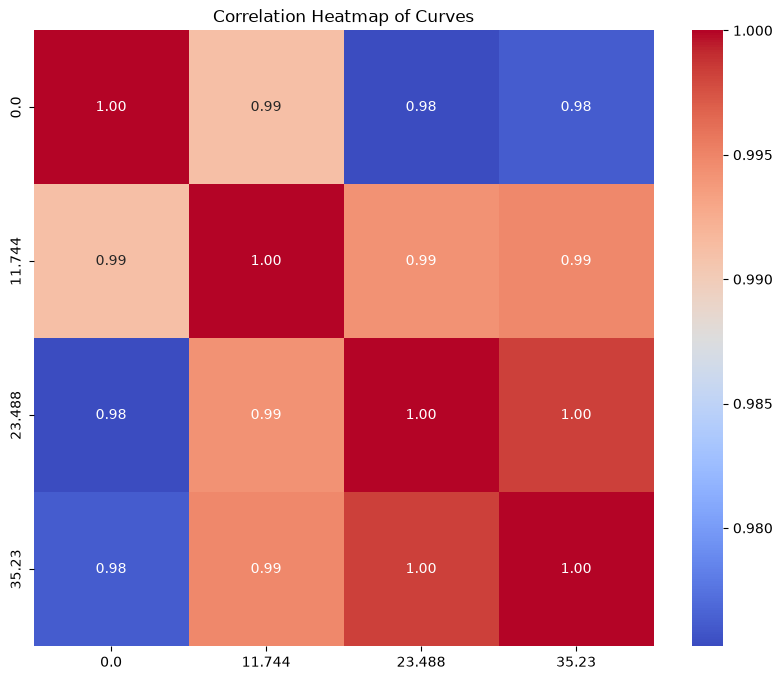

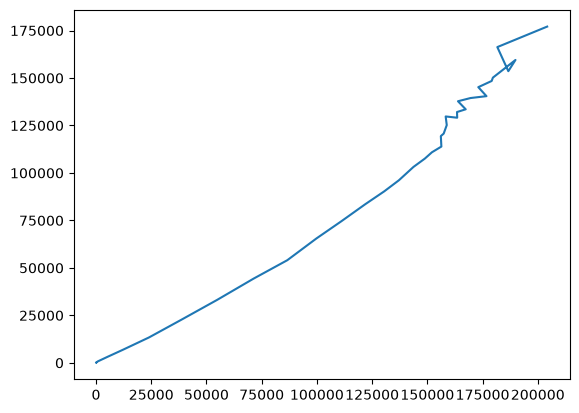

In [12]:
plt.figure(figsize=(10, 8))
sns.heatmap(df_side[xi_side[:]].corr(method="pearson"), annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Correlation Heatmap of Curves")
plt.show()

plt.plot(data_side_cor[:,0],data_side_cor[:,1])

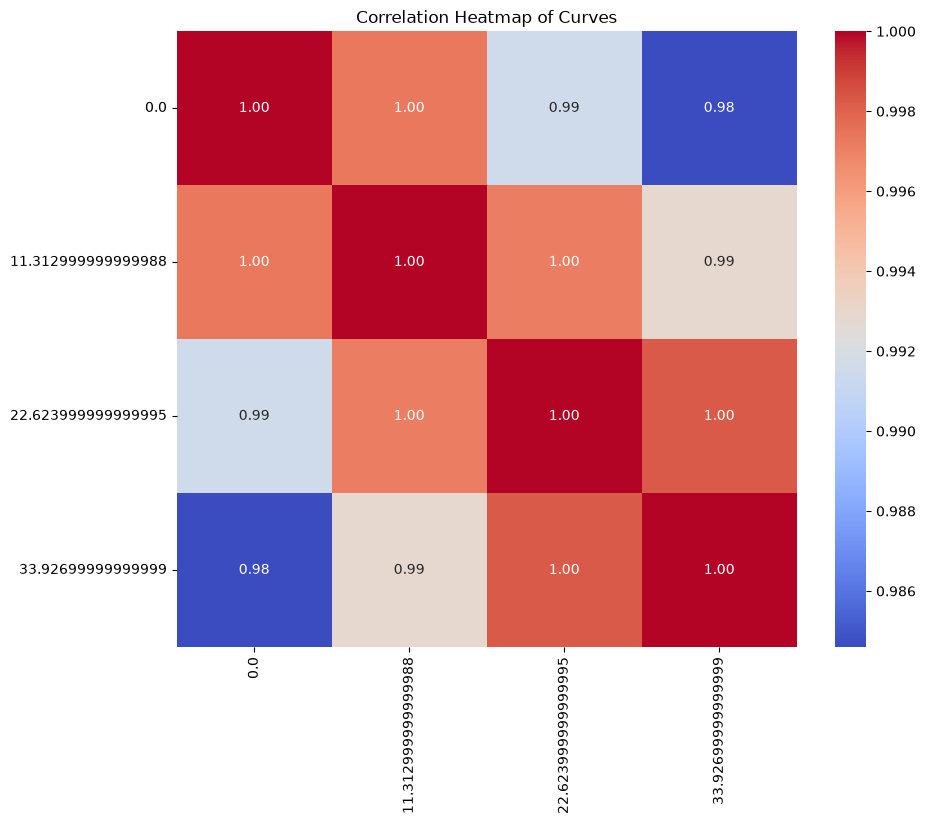

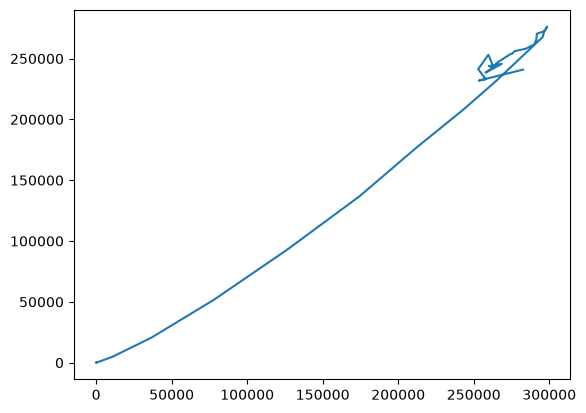

In [13]:
plt.figure(figsize=(10, 8))
sns.heatmap(df_low[xi_low[:]].corr(method="pearson"), annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Correlation Heatmap of Curves")
plt.show()

plt.plot(data_low_cor[:,0],data_low_cor[:,1])

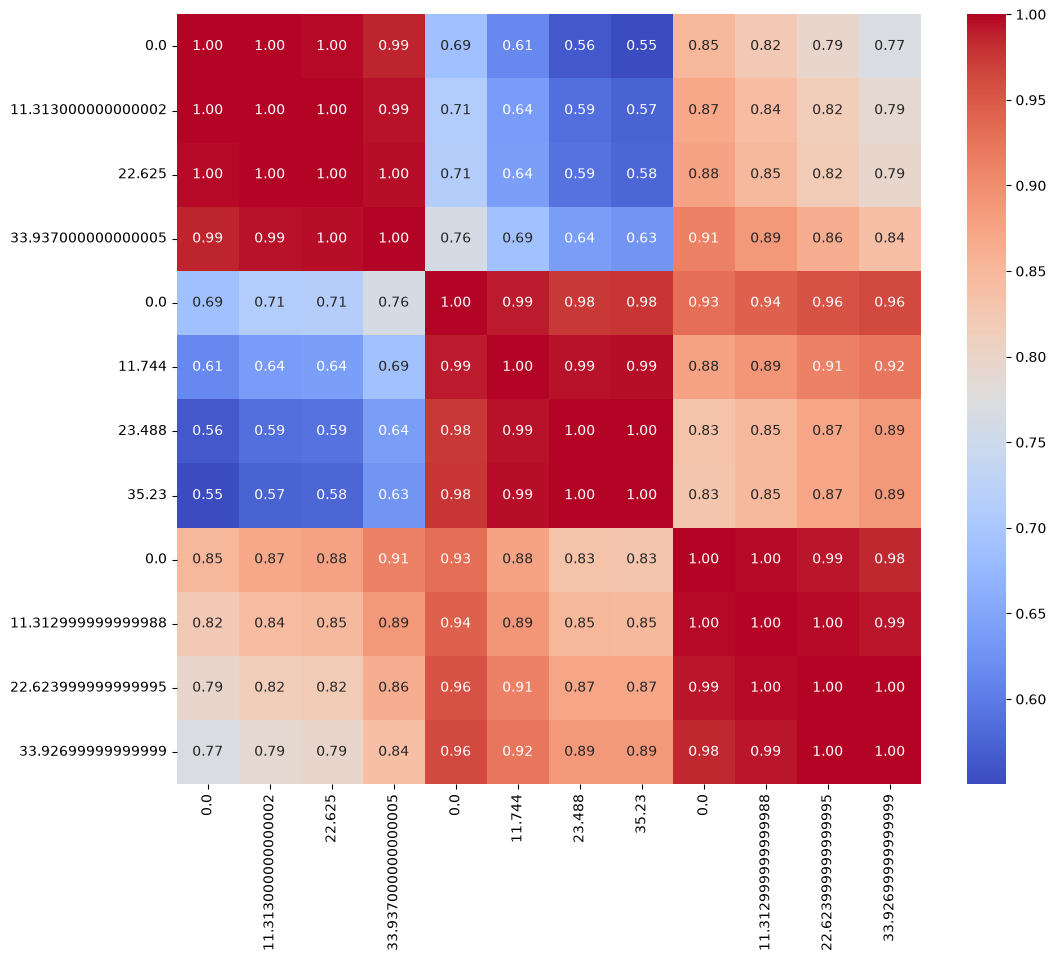

In [14]:
# Step 1: Concatenate the dataframes along the columns
df_combined = pd.concat([df_up[xi_up[:]], df_side[xi_side[:]], df_low[xi_low[:]]], axis=1)

# Step 2: Compute the correlation matrix for the concatenated dataframe
combined_corr = df_combined.corr(method="pearson")

plt.figure(figsize=(12, 10))
sns.heatmap(combined_corr, annot=True, fmt=".2f", cmap='coolwarm')
plt.title("")
plt.show()

In [15]:
df_combined

,0.000,11.313,22.625,33.937,0.000,11.744,23.488,35.230,0.000,11.313,22.624,33.927
0,142.569065,134.417903,117.392815,110.373846,118.322619,130.929216,135.158640,140.672003,85.051519,84.231640,93.219487,91.472584
1,224.666764,204.481048,180.966077,168.261147,178.281714,192.724858,209.606117,236.830544,140.930091,116.682083,125.769471,100.966229
2,183.687425,177.744051,164.876307,166.479271,163.386006,178.458188,189.858761,208.529515,118.544421,117.174283,112.311701,118.694441
3,191.769538,173.217923,159.863658,148.311726,162.657838,175.108431,176.419012,194.712786,130.998406,130.886006,122.397572,152.239793
4,233.222833,190.141398,178.722052,163.395910,158.500232,168.398433,189.961843,199.865308,147.920408,115.101565,132.253925,132.778237
5,3615.790593,1372.489232,429.700690,221.645342,215.894203,225.307389,230.531760,238.049420,151.185721,153.513531,164.546284,174.317716
6,28002.308283,15174.040181,8737.473082,3406.763371,376.312926,386.222312,336.452185,323.590928,170.705596,188.795024,168.549583,199.972986
7,96385.862833,60262.955151,41108.479198,19977.289403,803.049988,753.000173,555.516299,470.539997,299.172237,197.070998,223.094400,199.374707
8,196993.937980,138259.805535,107130.147386,64255.286899,1995.145922,1405.172729,930.877909,750.012920,1999.605717,872.260284,401.663960,276.242300
9,293055.283064,220168.246110,184952.364081,130435.852952,5012.227682,3055.617451,1615.132687,1142.733264,10899.081248,4899.234933,2454.946105,1109.933140


Selected columns: ['upper ROI1', 'upper ROI2', 'upper ROI3', 'upper ROI4', 'side ROI1', 'side ROI2', 'side ROI3', 'side ROI4', 'lower ROI1', 'lower ROI2', 'lower ROI3', 'lower ROI4']
Reference shape: (42,)
col='upper ROI1', shape=(42,), type=<class 'pandas.Series'>
col='upper ROI2', shape=(42,), type=<class 'pandas.Series'>
col='upper ROI3', shape=(42,), type=<class 'pandas.Series'>
col='upper ROI4', shape=(42,), type=<class 'pandas.Series'>
col='side ROI1', shape=(42,), type=<class 'pandas.Series'>
col='side ROI2', shape=(42,), type=<class 'pandas.Series'>
col='side ROI3', shape=(42,), type=<class 'pandas.Series'>
col='side ROI4', shape=(42,), type=<class 'pandas.Series'>
col='lower ROI1', shape=(42,), type=<class 'pandas.Series'>
col='lower ROI2', shape=(42,), type=<class 'pandas.Series'>
col='lower ROI3', shape=(42,), type=<class 'pandas.Series'>
col='lower ROI4', shape=(42,), type=<class 'pandas.Series'>
shift=-6.59, scale=4.52, loss=964862000143.9012
shift=3.91, scale=13.72, loss=

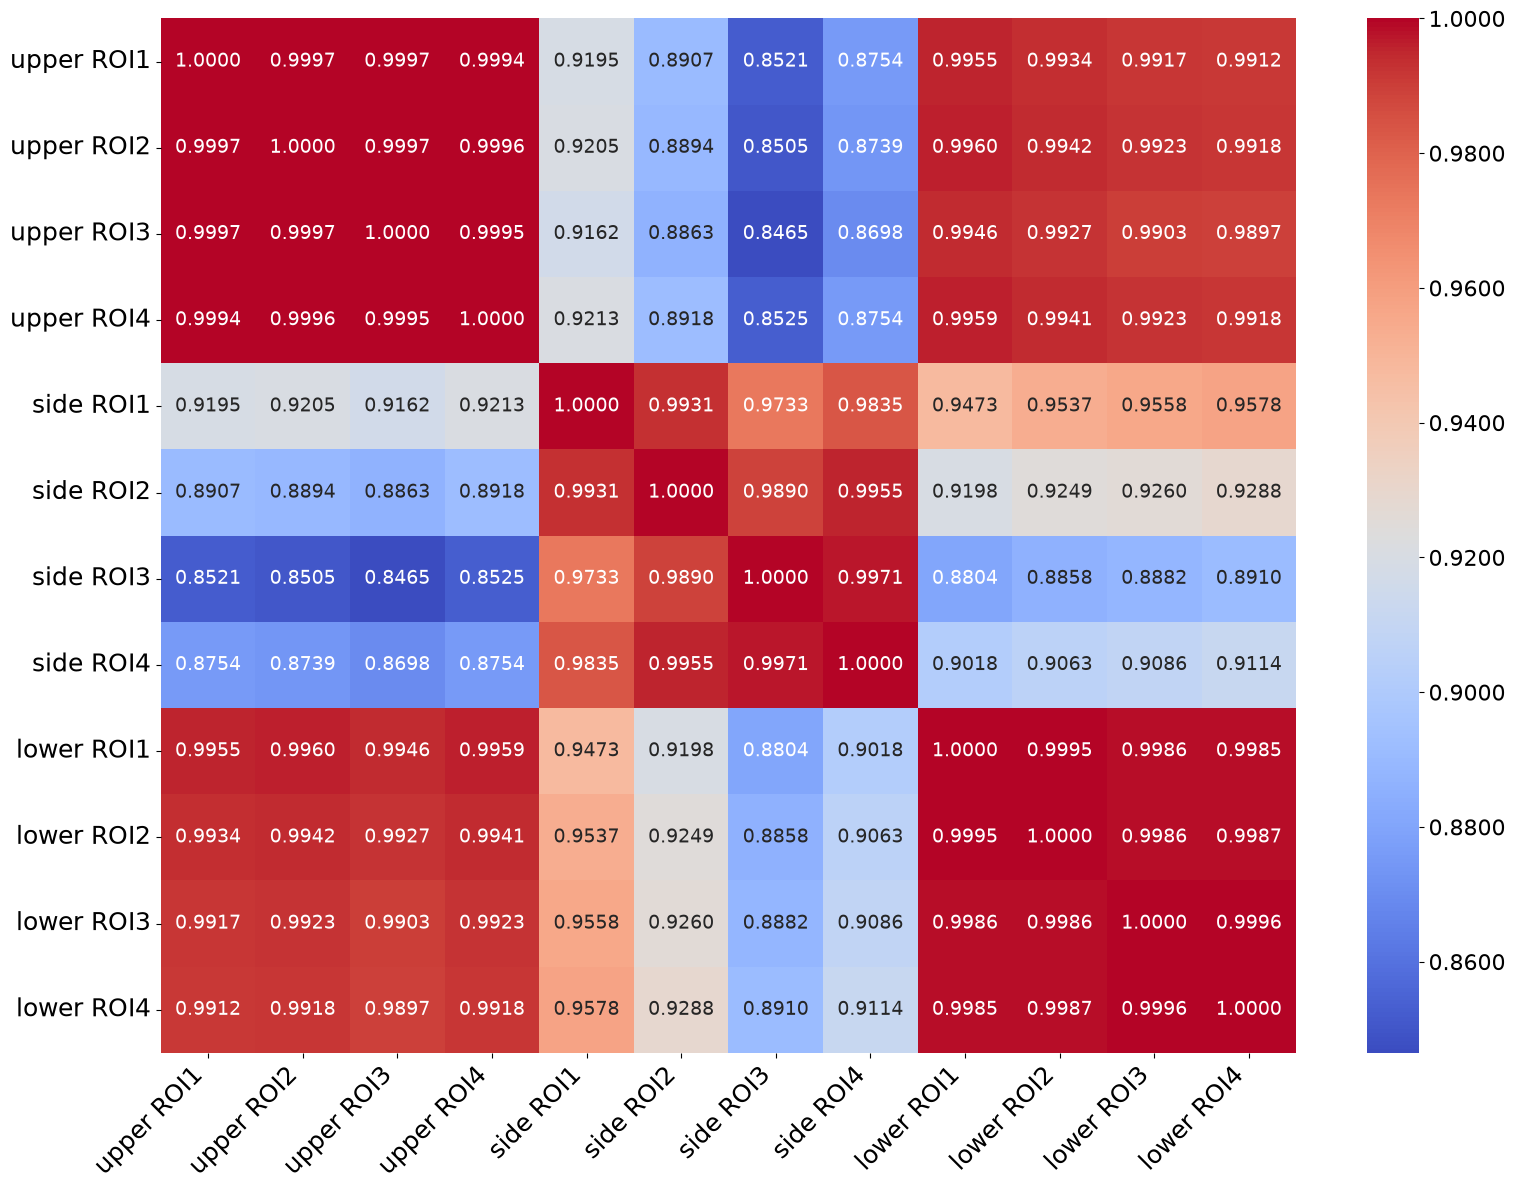

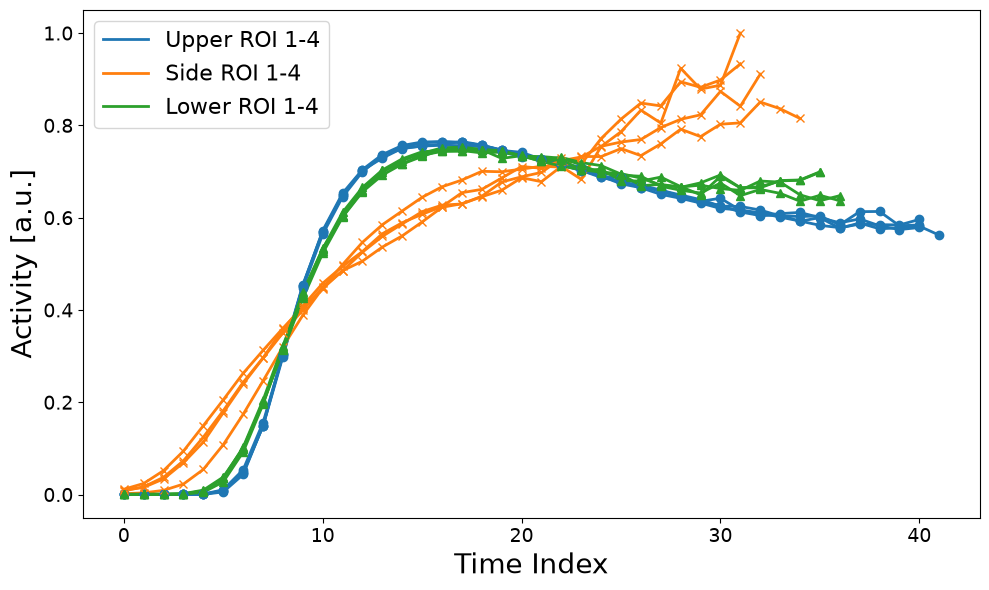

In [16]:
# ====================
# IMPORTS
# ====================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.interpolate import interp1d
from scipy.optimize import minimize, differential_evolution
from scipy.stats import pearsonr

# ====================
# LOAD AND PREP DATA
# ====================
data = df_combined.copy()

# Rename columns for disambiguation
group_prefixes = ['upper', 'side', 'lower']
columns_per_group = 4
new_columns = [f"{group} ROI{i+1}" for group in group_prefixes for i in range(columns_per_group)]
data.columns = new_columns

# Define groups
xi_upper = ['upper ROI1', 'upper ROI2', 'upper ROI3', 'upper ROI4']
xi_sides  = ['side ROI1', 'side ROI2', 'side ROI3', 'side ROI4']
xi_lower = ['lower ROI1', 'lower ROI2', 'lower ROI3', 'lower ROI4']

# ====================
# FUNCTION DEFINITIONS
# ====================
def shift_curve_interp(curve, shift, target_len):
    """
    Shift curve by a (possibly fractional) amount using interpolation.
    Fills out-of-bounds values with NaN.
    """
    x = np.arange(len(curve))
    interpolator = interp1d(x, curve, kind='linear', bounds_error=False, fill_value=np.nan)
    x_shifted = np.arange(target_len) + shift
    return interpolator(x_shifted)

def optimize_shift_and_scale(curve, reference, search_bounds=(-10, 15), scale_bounds=(0.1, 15.0)):
    """
    Find optimal (time shift, amplitude scale) to align curve to reference.
    """
    def loss_fn(params):
        shift, scale = params
        shifted = shift_curve_interp(curve, shift, len(reference)) * scale

        valid = ~np.isnan(shifted) & ~np.isnan(reference)
        if np.sum(valid) < 2:
            print(f"Too few valid points for shift={shift:.2f}, scale={scale:.2f}")
            return np.inf

        residuals = (shifted - reference) ** 2
        weights = np.ones(len(reference))
        weights[:len(reference) // 2] *= 2.0
        weights = weights[valid]
        residuals = residuals[valid]

        weights /= np.sum(weights)
        loss = np.sum(weights * residuals)

        print(f"shift={shift:.2f}, scale={scale:.2f}, loss={loss:.4f}")
        return loss

    bounds = [search_bounds, scale_bounds]
    result = differential_evolution(loss_fn, bounds)
    return result.x  # (best_shift, best_scale)

# ====================
# DATA SELECTION
# ====================
selected_cols = xi_upper + xi_sides + xi_lower
custom_names = new_columns#[f"ROI{i+1}" for i in range(len(selected_cols))]

print("Selected columns:", selected_cols)
print("Reference shape:", data[selected_cols[0]].shape)

for col in selected_cols:
    val = data[col]
    print(f"{col=}, shape={val.shape}, type={type(val)}")

# ====================
# ALIGNMENT
# ====================
aligned_curves = {}
shifts = {}

# Use unscaled reference (first curve)
ref_curve = data[selected_cols[0]].to_numpy(dtype=float)
aligned_curves[custom_names[0]] = ref_curve
shifts[custom_names[0]] = (0.0, 1.0)

for name, col in zip(custom_names[1:], selected_cols[1:]):
    curve = data[col].to_numpy(dtype=float)

    opt_shift, opt_scale = optimize_shift_and_scale(curve, ref_curve)
    aligned = shift_curve_interp(curve, opt_shift, len(ref_curve)) * opt_scale

    aligned_curves[name] = aligned
    shifts[name] = (opt_shift, opt_scale)

aligned_data = pd.DataFrame(aligned_curves)
aligned_data = aligned_data / aligned_data.max().max()

# ====================
# PLOTS
# ====================
print("Optimal shifts (time, scale):")
for name, (shift, scale) in shifts.items():
    print(f"{name}: Δt = {shift:.2f}, scale = {scale:.3f}")

plt.figure(figsize=(16, 12))

# Compute correlation separately to reformat colorbar later
corr_matrix = aligned_data.corr(method="pearson", min_periods=4)

ax = sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".4f",
    cmap="coolwarm",
    annot_kws={"size": 14},
    cbar_kws={"format": "%.4f"}  # Format colorbar to 4 decimal places
)

# Increase font size of tick labels
plt.xticks(fontsize=18, rotation=45, ha="right")
plt.yticks(fontsize=18, rotation=0)

# Resize colorbar label font and ticks
colorbar = ax.collections[0].colorbar
colorbar.ax.tick_params(labelsize=16)

plt.title("", fontsize=20)
plt.tight_layout()
plt.savefig("output/figures/poplar_branch_pearson.pdf", format="pdf")  
plt.show()

# Assume 1 minute per time point
dt = 1.0  # or use your actual time vector if available
time = np.arange(aligned_data.shape[0]) * dt

# Split by ROI group (3 per group)
exp_data_upper = aligned_data.iloc[:, 0:4].values
exp_data_side = aligned_data.iloc[:, 4:8].values
exp_data_lower = aligned_data.iloc[:, 8:12].values

plt.style.use('default')
plt.figure(figsize=(10, 6))

plt.xticks(fontsize=14)
plt.yticks(fontsize=14) 
plt.xlabel("Time Index", fontsize=20)
plt.ylabel("Activity [a.u.]", fontsize=20)

# Match simulation plot style
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

# Plot experimental data as lines
plt.plot(time, exp_data_upper, color=colors[0], label="Upper ROI 1-4", linewidth=2)
plt.plot(time, exp_data_side, color=colors[1], label="Side ROI 1-4", linewidth=2)
plt.plot(time, exp_data_lower, color=colors[2], label="Lower ROI 1-4", linewidth=2)

# Optional: also overlay with markers
plt.plot(time, exp_data_upper, 'o', color=colors[0], markersize=6)
plt.plot(time, exp_data_side, 'x', color=colors[1], markersize=6)
plt.plot(time, exp_data_lower, '^', color=colors[2], markersize=6)

# Remove duplicate legend entries
handles, labels = plt.gca().get_legend_handles_labels()
unique = dict(zip(labels, handles))
plt.legend(unique.values(), unique.keys(), fontsize=16)

plt.tight_layout()
plt.savefig("output/figures/poplar_branch_aligned.pdf", format="pdf")  
plt.show()


In [17]:
df_combined

,0.000,11.313,22.625,33.937,0.000,11.744,23.488,35.230,0.000,11.313,22.624,33.927
0,142.569065,134.417903,117.392815,110.373846,118.322619,130.929216,135.158640,140.672003,85.051519,84.231640,93.219487,91.472584
1,224.666764,204.481048,180.966077,168.261147,178.281714,192.724858,209.606117,236.830544,140.930091,116.682083,125.769471,100.966229
2,183.687425,177.744051,164.876307,166.479271,163.386006,178.458188,189.858761,208.529515,118.544421,117.174283,112.311701,118.694441
3,191.769538,173.217923,159.863658,148.311726,162.657838,175.108431,176.419012,194.712786,130.998406,130.886006,122.397572,152.239793
4,233.222833,190.141398,178.722052,163.395910,158.500232,168.398433,189.961843,199.865308,147.920408,115.101565,132.253925,132.778237
5,3615.790593,1372.489232,429.700690,221.645342,215.894203,225.307389,230.531760,238.049420,151.185721,153.513531,164.546284,174.317716
6,28002.308283,15174.040181,8737.473082,3406.763371,376.312926,386.222312,336.452185,323.590928,170.705596,188.795024,168.549583,199.972986
7,96385.862833,60262.955151,41108.479198,19977.289403,803.049988,753.000173,555.516299,470.539997,299.172237,197.070998,223.094400,199.374707
8,196993.937980,138259.805535,107130.147386,64255.286899,1995.145922,1405.172729,930.877909,750.012920,1999.605717,872.260284,401.663960,276.242300
9,293055.283064,220168.246110,184952.364081,130435.852952,5012.227682,3055.617451,1615.132687,1142.733264,10899.081248,4899.234933,2454.946105,1109.933140


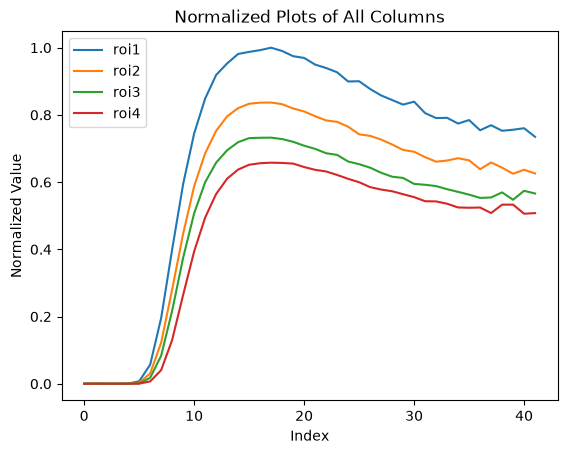

In [19]:
rois_up = plot_all_columns(data_up_cor)

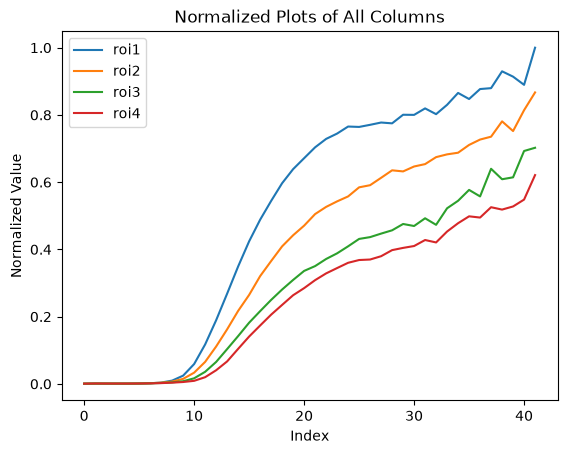

In [20]:
rois_side = plot_all_columns(data_side_cor)


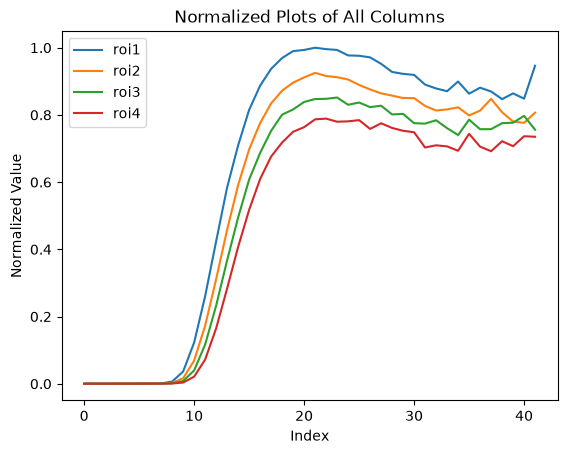

In [21]:
rois_low = plot_all_columns(data_low_cor)

In [22]:
rois_up

{'roi1': array([2.89069260e-04, 4.55528381e-04, 3.72439758e-04, 3.88826837e-04,
        4.72876440e-04, 7.33128125e-03, 5.67767387e-02, 1.95429423e-01,
        3.99419692e-01, 5.94191131e-01, 7.44661877e-01, 8.48531665e-01,
        9.18846528e-01, 9.53148985e-01, 9.81375044e-01, 9.87497852e-01,
        9.92750967e-01, 1.00000000e+00, 9.90219374e-01, 9.74790425e-01,
        9.69573310e-01, 9.49781504e-01, 9.39551126e-01, 9.26823436e-01,
        8.99437555e-01, 9.00261487e-01, 8.77171284e-01, 8.57987985e-01,
        8.44278513e-01, 8.30669366e-01, 8.39427309e-01, 8.05352017e-01,
        7.90674079e-01, 7.91343772e-01, 7.74233762e-01, 7.84658691e-01,
        7.54283777e-01, 7.69335567e-01, 7.52784577e-01, 7.55872122e-01,
        7.60385283e-01, 7.34842847e-01]),
 'roi2': array([2.72542180e-04, 4.14600358e-04, 3.60389131e-04, 3.51212073e-04,
        3.85525663e-04, 2.78282282e-03, 3.07664820e-02, 1.22187572e-01,
        2.80331920e-01, 4.46407305e-01, 5.87412890e-01, 6.85583911e-01,
      

In [23]:
xi_side

array([ 0.   , 11.744, 23.488, 35.23 ])

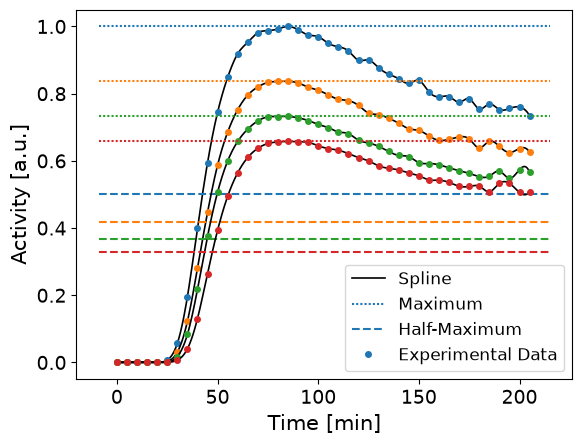

In [24]:
results_up = process_and_plot_rois(rois_up, t, "output/figures/upcor.pdf")


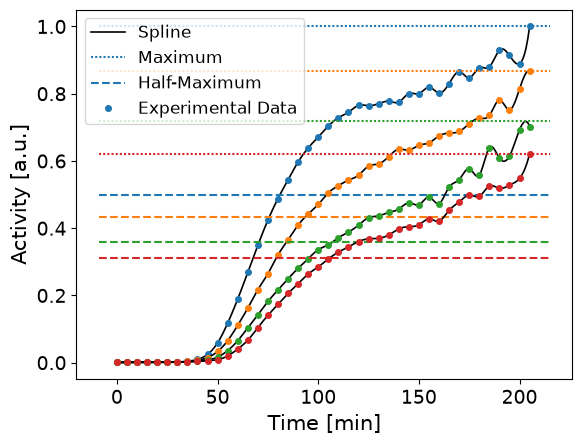

In [25]:
results_side = process_and_plot_rois(rois_side, t, "output/figures/sidecor.pdf")


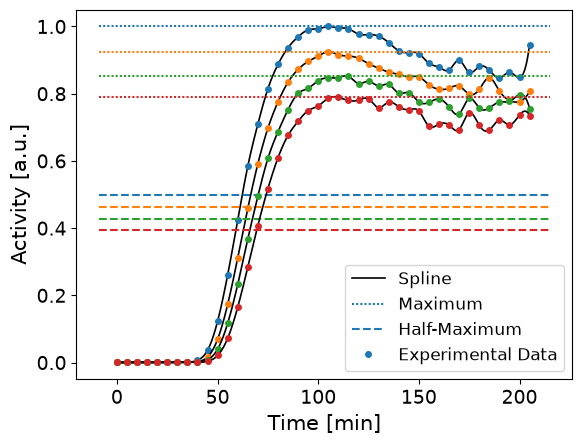

In [26]:
results_low = process_and_plot_rois(rois_low, t, "output/figures/lowcor.pdf")


[   6.92547603 -292.4238171 ] 1.2471108752846312 0.18007583450322895


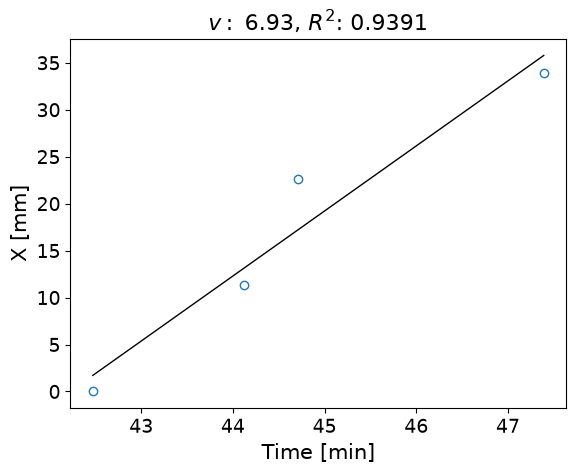

In [27]:
hmaxi = np.array(list(compute_hmax_times(results_up,np.linspace(0,205,500)).values()))
points=np.array(xi_up, dtype="float")

Iv=np.ones((len(hmaxi),1))
Mv=np.array(np.append(Iv,hmaxi.reshape(len(hmaxi),1),axis=1))

mbinter_v=np.array([]).reshape(0,3)
b1v, m1v = lstsq(Mv, points)[0]
mbinter_v = np.vstack((mbinter_v, (m1v, b1v, -b1v/m1v)))

plt.style.use('default')
    
plt.xticks(fontsize=14)
plt.yticks(fontsize=14) 

for i in range (0,len(mbinter_v)):
    plt.plot(hmaxi, mbinter_v[i][0]*np.array(hmaxi)+mbinter_v[i][1], label=np.round(mbinter_v[i][0],3),color='k', linewidth=1)    
    

    
#np.polyfit(intercepts,points,1)
plt.plot(hmaxi, points, marker='o', linestyle='None',markerfacecolor='none')

plt.xlabel("Time [min]",fontsize=15)
plt.ylabel("X [mm]",fontsize=15)
plt.title(f"$v:$ {np.around(mbinter_v[0][0],2)}, $R^2$: {np.around(np.corrcoef(hmaxi, points)[0,1]**2, 4)}", fontsize=16)
np.corrcoef(hmaxi, points)[0,1]**2

fit, V=np.polyfit(hmaxi,points,1, cov=True)
relative_uncertainty = np.sqrt(V[0][0]) / fit[0]

print(fit,np.sqrt(V[0][0]),relative_uncertainty)

np.corrcoef(hmaxi, points)[0,1]**2
plt.savefig("output/figures/anaupcor.pdf", format="pdf")  

In [28]:
xi_side

array([ 0.   , 11.744, 23.488, 35.23 ])

[  1.15667545 -94.33011013] 0.33693604269029304 0.2912969603577283


array([ 81.00767727,  93.57846359, 107.1155437 , 105.42716869])

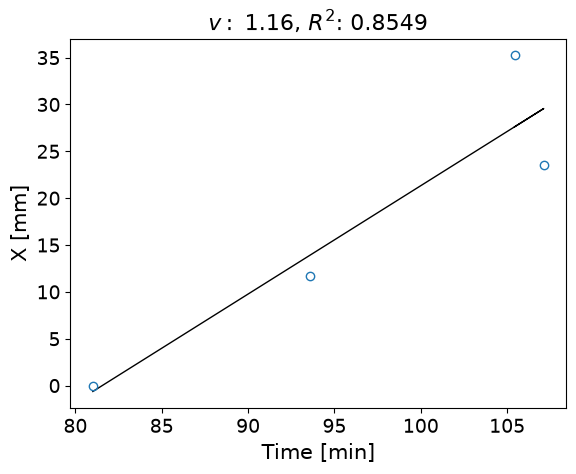

In [29]:
hmaxi = np.array(list(compute_hmax_times(results_side,np.linspace(0,205,500)).values()))
points=np.array(xi_side, dtype="float")

Iv=np.ones((len(hmaxi),1))
Mv=np.array(np.append(Iv,hmaxi.reshape(len(hmaxi),1),axis=1))

mbinter_v=np.array([]).reshape(0,3)
b1v, m1v = lstsq(Mv, points)[0]
mbinter_v = np.vstack((mbinter_v, (m1v, b1v, -b1v/m1v)))

plt.style.use('default')
    
plt.xticks(fontsize=14)
plt.yticks(fontsize=14) 

for i in range (0,len(mbinter_v)):
    plt.plot(hmaxi, mbinter_v[i][0]*np.array(hmaxi)+mbinter_v[i][1], label=np.round(mbinter_v[i][0],3),color='k', linewidth=1)    
    

    
#np.polyfit(intercepts,points,1)
plt.plot(hmaxi, points, marker='o', linestyle='None',markerfacecolor='none')

plt.xlabel("Time [min]",fontsize=15)
plt.ylabel("X [mm]",fontsize=15)
plt.title(f"$v:$ {np.around(mbinter_v[0][0],2)}, $R^2$: {np.around(np.corrcoef(hmaxi, points)[0,1]**2, 4)}", fontsize=16)
np.corrcoef(hmaxi, points)[0,1]**2

fit, V=np.polyfit(hmaxi,points,1, cov=True)
relative_uncertainty = np.sqrt(V[0][0]) / fit[0]

print(fit,np.sqrt(V[0][0]),relative_uncertainty)

np.corrcoef(hmaxi, points)[0,1]**2
plt.savefig("output/figures/anasidecor.pdf", format="pdf")  

hmaxi

[   4.73129145 -295.52693021] 0.23115142458146407 0.04885588367112137


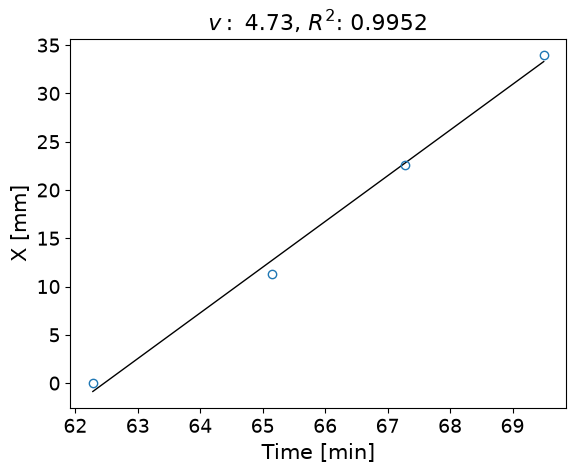

In [30]:
hmaxi = np.array(list(compute_hmax_times(results_low,np.linspace(0,205,500)).values()))
points=np.array(xi_low, dtype="float")

Iv=np.ones((len(hmaxi),1))
Mv=np.array(np.append(Iv,hmaxi.reshape(len(hmaxi),1),axis=1))

mbinter_v=np.array([]).reshape(0,3)
b1v, m1v = lstsq(Mv, points)[0]
mbinter_v = np.vstack((mbinter_v, (m1v, b1v, -b1v/m1v)))

plt.style.use('default')
    
plt.xticks(fontsize=14)
plt.yticks(fontsize=14) 

for i in range (0,len(mbinter_v)):
    plt.plot(hmaxi, mbinter_v[i][0]*np.array(hmaxi)+mbinter_v[i][1], label=np.round(mbinter_v[i][0],3),color='k', linewidth=1)    
    

    
#np.polyfit(intercepts,points,1)
plt.plot(hmaxi, points, marker='o', linestyle='None',markerfacecolor='none')

plt.xlabel("Time [min]",fontsize=15)
plt.ylabel("X [mm]",fontsize=15)
plt.title(f"$v:$ {np.around(mbinter_v[0][0],2)}, $R^2$: {np.around(np.corrcoef(hmaxi, points)[0,1]**2, 4)}", fontsize=16)
np.corrcoef(hmaxi, points)[0,1]**2

fit, V=np.polyfit(hmaxi,points,1, cov=True)
relative_uncertainty = np.sqrt(V[0][0]) / fit[0]

print(fit,np.sqrt(V[0][0]),relative_uncertainty)

np.corrcoef(hmaxi, points)[0,1]**2
plt.savefig("output/figures/analowcor.pdf", format="pdf")  

In [31]:
max1_up=np.max(results_up["roi1"]["cubic_spline"](np.linspace(0,140,500)))
max2_up=np.max(results_up["roi2"]["cubic_spline"](np.linspace(0,140,500)))
max3_up=np.max(results_up["roi3"]["cubic_spline"](np.linspace(0,140,500)))

max1_side=np.max(results_side["roi1"]["cubic_spline"](np.linspace(0,140,500)))
max2_side=np.max(results_side["roi2"]["cubic_spline"](np.linspace(0,140,500)))
max3_side=np.max(results_side["roi3"]["cubic_spline"](np.linspace(0,140,500)))

max1_low=np.max(results_low["roi1"]["cubic_spline"](np.linspace(0,140,500)))
max2_low=np.max(results_low["roi2"]["cubic_spline"](np.linspace(0,140,500)))
max3_low=np.max(results_low["roi3"]["cubic_spline"](np.linspace(0,140,500)))

maxi_up=[max1_up, max2_up, max3_up]
maxi_side=[max1_side, max2_side, max3_side]
maxi_low=[max1_low, max2_low, max3_low]

In [32]:
ratios_up = [maxi_up[i] / maxi_up[i + 1] for i in range(len(maxi_up) - 1)]
ratios_side = [maxi_side[i] / maxi_side[i + 1] for i in range(len(maxi_side) - 1)]
ratios_low = [maxi_low[i] / maxi_low[i + 1] for i in range(len(maxi_low) - 1)]

In [33]:
xi_up, xi_side, xi_low

(array([ 0.   , 11.313, 22.625, 33.937]),
 array([ 0.   , 11.744, 23.488, 35.23 ]),
 array([ 0.   , 11.313, 22.624, 33.927]))

In [34]:
ratios_up

[np.float64(1.1947607646243026), np.float64(1.1426715929150009)]

In [35]:
ratios_side

[np.float64(1.2240829805474003), np.float64(1.3905687716202024)]

In [36]:
ratios_low 

[np.float64(1.0809438634194328), np.float64(1.0841985519177189)]